# 1. Пилот: UCF101 и сравнение первых моделей

Этот ноутбук оформляет **уже проведённые** эксперименты 26–27 сентября 2026 года. Он читает сохранённые результаты, а обучение находится в `scripts/train.py`. Ноутбуки подготовлены после экспериментов для показа хода исследования.

Сначала проверялось, можно ли распознавать спорт по нескольким кадрам и насколько тяжёлы разные архитектуры. Использован первый shard UCF101: четыре действия, сопоставленные четырём видам спорта. Это ограниченный пилот, а не официальный benchmark UCF101. Меток пола и возраста здесь нет.

Код: `download_ucf101.py`, `prepare_ucf101.py`, `eda.py`, `audit_duplicates.py`, `zero_shot_siglip.py`, `train.py`, `benchmark.py`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "scripts/train_vk_bundle.py").is_file()
             and (p / "configs/experiment_index.csv").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Запустите ноутбук внутри sports_video_repo")

def load_json(path):
    return json.loads((ROOT / path).read_text(encoding="utf-8"))

def load_jsonl(path):
    return [json.loads(line) for line in (ROOT / path).read_text(encoding="utf-8").splitlines() if line]

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True})
print("Читаем сохранённые результаты; обучение и скачивание не запускаются.")

Читаем сохранённые результаты; обучение и скачивание не запускаются.


## Состав выборки и защита от пересечения исходных групп

In [2]:
eda = load_json("outputs/eda.json")
display(pd.DataFrame(eda["split_by_sport"]).T[["train", "val", "test"]])
splits = {part: pd.read_csv(ROOT / f"data/splits/{part}.csv") for part in ("train", "val", "test")}
groups = {part: set(df.source_video_id) for part, df in splits.items()}
assert not (groups["train"] & groups["val"] or groups["train"] & groups["test"] or groups["val"] & groups["test"])
display(pd.DataFrame([{ "часть": part, "клипов": len(df), "исходных групп": len(groups[part])}
                      for part, df in splits.items()]))
print("Всего клипов:", eda["clips"], "Медианная длительность, с:", round(eda["statistics"]["duration_sec"]["50%"], 2))
print("Категории пола и возраста:", eda["gender_counts"], eda["age_counts"])

,train,val,test
basketball,70,13,10
football,74,17,15
tennis,92,15,21
volleyball,61,15,15


,часть,клипов,исходных групп
0,train,297,60
1,val,60,13
2,test,61,13


Всего клипов: 418 Медианная длительность, с: 3.77
Категории пола и возраста: {} {}


## SigLIP: отправная точка без supervised обучения

In [3]:
siglip = load_json("outputs/E0_siglip/metrics.json")
display(pd.DataFrame([{
    "кадров": int(frames), "sport Macro-F1": result["sport_label"]["macro_f1"],
    "accuracy": result["sport_label"]["accuracy"], "мс/клип": result["runtime"]["ms_per_video"],
    "VRAM, МиБ": result["runtime"]["peak_inference_vram_mb"]}
    for frames, result in siglip.items()]).round(3))

,кадров,sport Macro-F1,accuracy,мс/клип,"VRAM, МиБ"
0,1,0.818,0.836,47.951,998.381
1,4,0.802,0.836,82.952,1004.473
2,8,0.863,0.885,138.892,1021.768


## Обучаемые модели и дополнительные проверки чувствительности

In [4]:
runs = ["E1_efficientnet_b0_1f_b2", "E2_efficientnet_b0_8f", "E3_dinov2_small_frozen_4f",
        "E4_x3d_xs_4f", "E5_r3d18_16f", "E1_efficientnet_b0_1f",
        "E1_efficientnet_b4_1f", "E2_efficientnet_b4_4f", "E3_vit_small_frozen_4f"]
table = []
for run in runs:
    cfg, met = load_json(f"outputs/{run}/config.json"), load_json(f"outputs/{run}/metrics.json")
    table.append({"запуск": run, "кадров": cfg["frames"], "эпох": cfg["epochs"],
        "batch": cfg["batch_size"], "encoder": "заморожен" if cfg["freeze"] else "дообучается",
        "sport Macro-F1": met["sport_label"]["macro_f1"], "accuracy": met["sport_label"]["accuracy"]})
display(pd.DataFrame(table).round(3))

,запуск,кадров,эпох,batch,encoder,sport Macro-F1,accuracy
0,E1_efficientnet_b0_1f_b2,1,2,2,дообучается,0.666,0.689
1,E2_efficientnet_b0_8f,8,2,2,дообучается,0.933,0.951
2,E3_dinov2_small_frozen_4f,4,4,8,заморожен,1.000,1.000
3,E4_x3d_xs_4f,4,2,4,дообучается,0.749,0.770
4,E5_r3d18_16f,16,2,4,дообучается,0.930,0.934
5,E1_efficientnet_b0_1f,1,2,8,дообучается,0.808,0.820
6,E1_efficientnet_b4_1f,1,2,4,дообучается,0.851,0.902
7,E2_efficientnet_b4_4f,4,2,2,дообучается,0.750,0.803
8,E3_vit_small_frozen_4f,4,4,8,заморожен,0.823,0.836


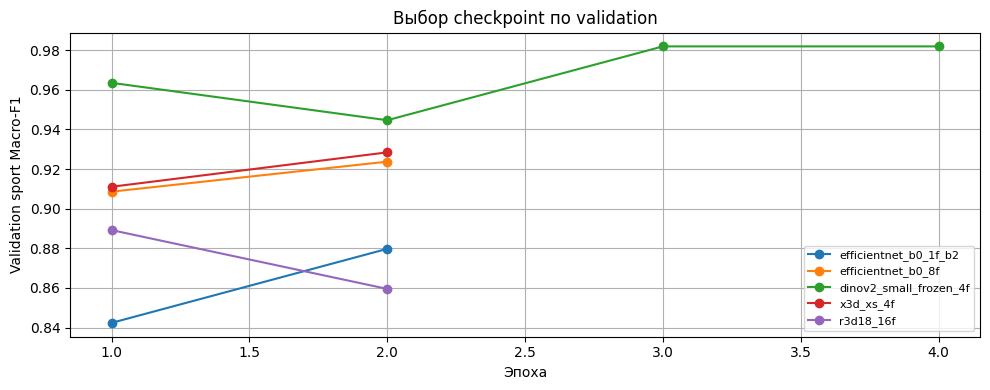

In [5]:
for run in runs[:5]:
    h = pd.DataFrame(load_json(f"outputs/{run}/history.json"))
    plt.plot(h.epoch, h.val_sport_macro_f1, marker="o", label=run.split("_", 1)[1])
plt.xlabel("Эпоха"); plt.ylabel("Validation sport Macro-F1"); plt.legend(fontsize=8)
plt.title("Выбор checkpoint по validation"); plt.tight_layout(); plt.show()

## Почему идеальный тест DINOv2 потребовал дополнительной проверки

In [6]:
audit = load_json("outputs/duplicate_audit.json")
display(pd.DataFrame([{k: v for k, v in audit.items() if k != "nearest_pairs"}]))
display(pd.DataFrame(audit["nearest_pairs"]).head())

,method,test_clips,minimum_distance,pairs_at_distance_5_or_less
0,64-bit dHash of the middle decoded frame,61,8,0


,test_clip_id,nearest_train_clip_id,hamming_distance
0,v_Basketball_g10_c01,v_SoccerPenalty_g18_c02,21
1,v_Basketball_g10_c02,v_TennisSwing_g11_c07,20
2,v_Basketball_g10_c03,v_Basketball_g07_c04,20
3,v_Basketball_g10_c04,v_TennisSwing_g14_c04,20
4,v_Basketball_g10_c05,v_TennisSwing_g14_c02,22


DINOv2 распознала все 61 тестовый клип этого маленького набора. Проверка dHash не нашла очевидных копий среднего кадра между train и test, но она не исключает похожие сцены и фоновые подсказки. Поэтому следующий шаг — проверка переноса на MultiSports и MUVY. Дополнительные B4/ViT и изменение batch сохранены отдельно: они не подменяют сравнение EfficientNet-B0 1f/8f с одинаковыми настройками.

Подробности: [исходный отчёт пилота](../docs/results/STAGE_1_RESULTS.md), [команды запусков](../docs/EXPERIMENT_COMMANDS.md).